In [5]:
import mrcfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Patch
import ipywidgets as widgets

from pathlib import Path
import matplotlib.pyplot as plt
# from napari import Viewer

import torch
import urllib3
from scipy.spatial.transform import Rotation
from torch_fourier_shell_correlation import fourier_shell_correlation
import mmdf
from torch_calculate_electrostatic_potential import (
    GridConfig,
    default_sublattice_radius,
    potential_from_structure_3d,
)
from torch_structure_manipulation import AtomicStructure, center_structure
from torch_fourier_filter.dose_weight import dose_weight_2d
from torch_ctf import calculate_ctf_2d
from torch_grid_utils import fftfreq_grid
from torch_fourier_slice import (
    backproject_2d_to_3d,
    project_3d_to_2d,
)
from torch_affine_utils.transforms_3d import Ry

In [6]:
### Define phantom volume sizes
z, y, x = 100, 512, 512 
pixel_size = 10 #Angstrom
phantom_tomo = np.ones((x, y, z))

PDB_ID_ribosome = "4v6x"  # 80S ribosome
PDB_ID_cohesin = "6wg3"  # Cohesin complex
PIXEL_SPACING = 10.0 # angstroms per pixel -> Nyquist at 20.0 A
VOLTAGE = 300  # in keV
BOX = 96  # 1280 A box
SNR_SPA = 5.0 
SNR_CET = 0.5
CACHE = Path.home() / ".cache" / "arp"
TILT_ANGLES = torch.arange(-54, 57, 3)
DOSE = [
    82.2, 79.8, 70.68, 68.4, 66.12, 54.72, 52.44, 50.16, 47.88, 41.04, 38.76, 31.92,
    29.64, 22.8, 20.52, 13.68, 11.4, 4.56, 2.28, 0, 6.84, 9.12,
    15.96, 18.24, 25.08, 27.36, 34.2, 36.48, 43.32, 45.6, 57, 59.28,
    61.559998, 63.84, 72.96, 75.24, 77.52
] # total dose over tilt-series in e-/A^2


In [7]:
def simulate_pdb(pdb_id: str, device: str = "cuda") -> torch.Tensor:
    """Download a PDB entry and simulate its potential in volts (cached on disk)."""
    CACHE.mkdir(parents=True, exist_ok=True)
    volume_path = CACHE / f"{pdb_id}_box{BOX}_{PIXEL_SPACING:g}apx_peng.pt"
    if volume_path.exists():
        return torch.load(volume_path)

    structure_path = CACHE / f"{pdb_id}.cif"
    if not structure_path.exists():
        print(f"downloading {pdb_id} from RCSB ...")
        response = urllib3.PoolManager().request(
            "GET", f"https://files.rcsb.org/download/{pdb_id}.cif"
        )
        if response.status != 200:
            raise RuntimeError(f"download of {pdb_id} failed: HTTP {response.status}")
        structure_path.write_bytes(response.data)

    print(f"simulating {pdb_id}: {BOX}^3 volume at {PIXEL_SPACING} A/px ...")
    atoms = center_structure(mmdf.read(str(structure_path)), zyx=False)
    structure = AtomicStructure.from_annotated_dataframe(atoms, device=device)
    grid_3d = GridConfig.from_grid_shape_and_voxel_size(
        grid_shape=(BOX, BOX, BOX),
        voxel_size=(PIXEL_SPACING,) * 3,
        center_zyx=(0.0, 0.0, 0.0),
        sublattice_radius=default_sublattice_radius(PIXEL_SPACING),
        device=torch.device(device),
    )
    volume = potential_from_structure_3d(
        structure, grid_3d,
        scattering_factors="peng_bonded", bonded_fallback="elemental",
    ).cpu()
    torch.save(volume, volume_path)
    return volume

ribosome = simulate_pdb(PDB_ID_ribosome, device="cpu")
cohesin = simulate_pdb(PDB_ID_cohesin, device="cpu")

# generate a CTF image
ctf_values = {
    "defocus": 3,  # in micrometers
    "astigmatism": 0.0,  # in micrometers
    "astigmatism_angle": 0.0,  # in degrees
    "voltage": VOLTAGE,  # in volts
    "spherical_aberration": 2.7, # mm float | torch.Tensor,
    "amplitude_contrast": 0.07, # float | torch.Tensor,
    "phase_shift": 0.0, # float | torch.Tensor,
    "pixel_size": PIXEL_SPACING, # float | torch.Tensor,
    "image_shape": (BOX, BOX), # tuple[int, int],
    "rfft": True, # bool,
    "fftshift": False, # bool,
    "beam_tilt_mrad": None, # torch.Tensor | None = None,
    "even_zernike_coeffs": None, # dict | None = None,
    "odd_zernike_coeffs": None, # dict | None = None,
    "transform_matrix": None, # torch.Tensor | None = None,
    "return_complex_ctf": False, # bool = False, 
}
# need to add minus sign for correct CTF, weird...
ctf_image = - calculate_ctf_2d(**ctf_values)

# cut-off beyond nyquist
frequency_grid = fftfreq_grid(image_shape=(BOX, BOX), rfft=True, fftshift=False, norm=True)
ctf_image[frequency_grid > 0.5] = 0

# create dose weighted CTF's
dose_per_tilt = torch.Tensor(DOSE)
# NOTE: the abs of the CTF is used because this correspond to phase-flip corrections
ctf_per_tilt = dose_weight_2d(
    image_dft=torch.abs(ctf_image).repeat(len(DOSE), 1, 1),
    image_shape=(BOX, BOX),
    pixel_size=PIXEL_SPACING,
    dose=dose_per_tilt,
    voltage=VOLTAGE,
)
# add tilt dependent dampening
ctf_per_tilt *= torch.cos(torch.deg2rad(TILT_ANGLES))[:, None, None]

## Simulate a single particle projection image

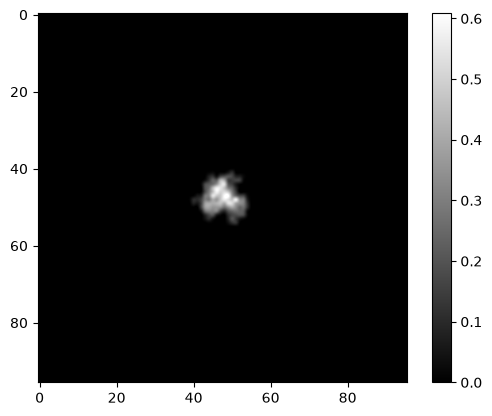

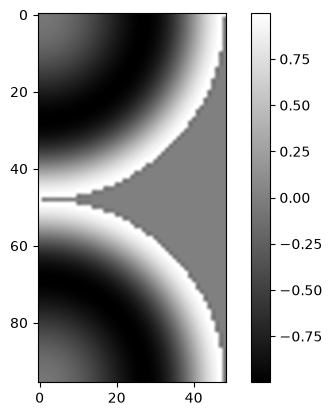

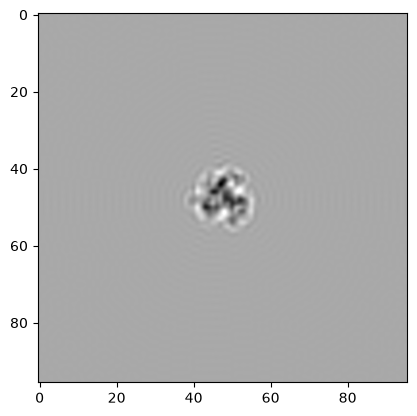

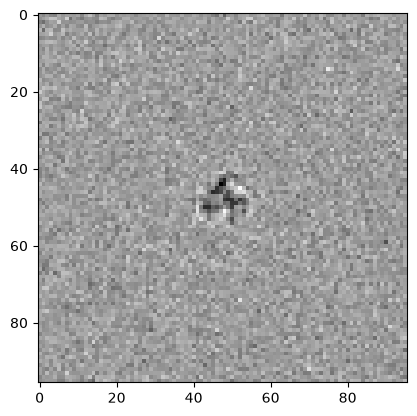

In [8]:
protein = cohesin
# protein = ribosome

# projection = ribosome.mean(dim=0) -> fourier slice teamtomo
phase = protein.mean(dim=0)
convolved = torch.fft.irfftn(torch.fft.rfftn(phase) * ctf_image, s=(BOX, BOX))

# # use a mask to find the signal only in the region with density -> exclude empty background for SNR
# # mask = projection > 0.05 * projection.max()
mask = phase > 0.05 * phase.max()

contrast = 2 * torch.fft.irfftn(torch.fft.rfftn(phase) * ctf_image, s=(BOX, BOX))  # weak-phase: I = 1 + 2·(CTF ⊛ φ)\n"

signal_var = convolved[mask].var()
# # the SNR for SPA is much higher because of the high exposure for the 2d projection ~35 e-/A^2
spa_noise_std = (signal_var / SNR_SPA).sqrt()
noisy = convolved + torch.randn_like(convolved) * spa_noise_std

plt.imshow(phase, cmap='gray', interpolation='spline16')
plt.colorbar()
plt.show()
plt.imshow(ctf_image, cmap='gray', interpolation='spline16')
plt.colorbar()
plt.show()
plt.imshow(contrast, cmap='gray', interpolation='spline16')
plt.show()
plt.imshow(noisy, cmap='gray', interpolation='nearest')
plt.show()

In [9]:
# ### Load the two proteins

# path = "C:\\Users\\ruben\\OneDrive - Delft University of Technology\\Documenten\\Nanobiology 6\\ARP\\protein_files"

# ## Ribosomes - emd_2938
# with mrcfile.open(f"{path}/emd_2938.map.gz", permissive=True) as mrc: 
#     vol_rib = mrc.data.astype(np.float32).copy() # shape (z, y, x) 
#     voxel_rib = mrc.voxel_size # Å per voxel, per axis 
#     origin_rib = mrc.header.origin

# ## Cohesin - emd_52297
# with mrcfile.open(f"{path}/emd_52297.map.gz", permissive=True) as mrc: 
#     vol_coh = mrc.data.astype(np.float32).copy() # shape (z, y, x) 
#     voxel_coh = mrc.voxel_size # Å per voxel, per axis 
#     origin_coh = mrc.header.origin

In [10]:
# print(f"The dim of ribosomes are {vol_rib.shape}, with voxelsize {voxel_rib}, origin at {origin_rib}")
# print(f"That means that ribosome takes {np.array(vol_rib.shape)*max(voxel_rib.tolist())/pixel_size} pixels")
# print(f"The dim of cohesin are {vol_coh.shape}, with voxelsize {voxel_coh}, origin at {origin_coh}")
# print(f"That means that cohesin takes {np.array(vol_coh.shape)*max(voxel_coh.tolist())/pixel_size} pixels")

## Place particles within phantom tomogram

In [11]:
from random import seed


def place_particles_spherical(mask, n, exclusion_radius, margin=0, seed=None, reserve_radius=None):
    """
    Randomly place up to n particle centers on voxels where mask == 1.
    Centers are returned in the input array's axis order.

    exclusion_radius controls spacing within this placement group. If
    reserve_radius is provided, the returned mask excludes that distance
    around each new center, for placement of another particle group.
    """
    rng = np.random.default_rng(seed)
    free = mask.astype(bool, copy=True)
    shape = free.shape

    if margin > 0:
        free[:margin] = free[-margin:] = False
        free[:, :margin] = free[:, -margin:] = False
        free[:, :, :margin] = free[:, :, -margin:] = False

    r = int(np.ceil(exclusion_radius))
    zz, yy, xx = np.ogrid[-r:r + 1, -r:r + 1, -r:r + 1]
    ball = (zz**2 + yy**2 + xx**2) <= exclusion_radius**2

    centers = []
    for _ in range(n):
        idx = np.flatnonzero(free)
        if idx.size == 0:
            print(f"No free positions left after {len(centers)} particles")
            break

        center = np.unravel_index(rng.choice(idx), shape)
        centers.append(center)

        lo = [max(ci - r, 0) for ci in center]
        hi = [min(ci + r + 1, size) for ci, size in zip(center, shape)]
        blo = [low - (ci - r) for low, ci in zip(lo, center)]
        bhi = [start + (high - low) for start, high, low in zip(blo, hi, lo)]

        free[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] &= ~ball[
            blo[0]:bhi[0], blo[1]:bhi[1], blo[2]:bhi[2]
        ]

    if reserve_radius is None:
        next_free = free
    else:
        next_free = mask.astype(bool, copy=True)
        reserve_r = int(np.ceil(reserve_radius))
        zz, yy, xx = np.ogrid[-reserve_r:reserve_r + 1, -reserve_r:reserve_r + 1, -reserve_r:reserve_r + 1]
        reserve_ball = (zz**2 + yy**2 + xx**2) <= reserve_radius**2

        for center in centers:
            lo = [max(ci - reserve_r, 0) for ci in center]
            hi = [min(ci + reserve_r + 1, size) for ci, size in zip(center, shape)]
            blo = [low - (ci - reserve_r) for low, ci in zip(lo, center)]
            bhi = [start + (high - low) for start, high, low in zip(blo, hi, lo)]

            next_free[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] &= ~reserve_ball[
                blo[0]:bhi[0], blo[1]:bhi[1], blo[2]:bhi[2]
            ]

    return np.array(centers, dtype=int).reshape(-1, 3), next_free

def place_particles_proteinspace(mask, shape, n, seed=None, threshold=0.05,
                                n_rotations=20, n_positions=200):
    """Place randomly rotated binary particles in free voxels of `mask`.
    Returns (centers, rotation_matrices, updated_free_mask)."""
    from scipy.ndimage import affine_transform

    free = np.asarray(mask).astype(bool, copy=True)
    particle = np.asarray(shape) >= threshold
    if not particle.any():
        raise ValueError("particle contains no voxels above threshold")

    # crop to the occupied bounding box -> much cheaper rotations
    nz = np.argwhere(particle)
    particle = particle[tuple(slice(a, b + 1) for a, b in zip(nz.min(0), nz.max(0)))]

    rng = np.random.default_rng(seed)
    vol_shape = np.array(free.shape)
    p_center = (np.array(particle.shape) - 1) / 2
    corners = np.array(np.meshgrid(*[(0, s - 1) for s in particle.shape],
                                indexing="ij")).reshape(3, -1).T - p_center

    centers, rotations = [], []
    for i in range(n):
        placed = False
        for _ in range(n_rotations):                      # new orientation if stuck
            rot = Rotation.random(random_state=rng)
            rc = rot.apply(corners)
            rmin = np.floor(rc.min(0)).astype(int)
            rshape = tuple(np.ceil(rc.max(0)).astype(int) - rmin + 1)
            inv = rot.as_matrix().T
            rotated = affine_transform(particle.astype(np.uint8), inv,
                                    offset=p_center + inv @ rmin,
                                    output_shape=rshape, order=0,
                                    prefilter=False).astype(bool)

            offsets = np.argwhere(rotated) + rmin         # voxel offsets w.r.t. center
            lo = -offsets.min(0)                          # valid center range so the
            hi = vol_shape - offsets.max(0)               # particle stays inside
            if np.any(hi <= lo):
                continue                                  # doesn't fit in this orientation

            for _ in range(n_positions):
                center = rng.integers(lo, hi)
                idx = tuple((offsets + center).T)
                if free[idx].all():
                    free[idx] = False
                    centers.append(center)
                    rotations.append(rot.as_matrix())
                    placed = True
                    break
            if placed:
                break

        if not placed:
            print(f"Placed {len(centers)}/{n}; no fit found for particle {i + 1}")
            break
        print(f"Placed {len(centers)}/{n} particles")

    return (np.asarray(centers, int).reshape(-1, 3),
            np.asarray(rotations, float).reshape(-1, 3, 3),
            free)


In [12]:
### Define the places + orientations where proteins will be inserted + z-slice
n_proteins = 200
distribution = 0.9
n_rib = round(n_proteins * distribution)
n_coh = n_proteins - n_rib
protein = ribosome
rib_centers, rib_rotations, rib_mask = place_particles_proteinspace(mask=phantom_tomo, shape=protein.numpy(), n=n_rib, seed=42)
coh_centers, coh_rotations, coh_mask = place_particles_proteinspace(mask=rib_mask, shape=cohesin.numpy(), n=n_coh, seed=42)

plot = False
if plot:
    def plot_particle_slice(z_slice):
        fig, ax = plt.subplots(figsize=(8, 8))
        image = ax.imshow(
            coh_mask[:, :, z_slice].T,
            cmap="gray",
            origin="lower",
            extent=(0, x, 0, y),
            interpolation="nearest",
            vmin=0,
            vmax=max(float(np.max(coh_mask)), 1e-12),
        )
        ax.set_aspect("equal")
        ax.set_xlabel("X (voxels)")
        ax.set_ylabel("Y (voxels)")
        ax.set_title(f"Tomogram at Z = {z_slice}")
        fig.colorbar(image, ax=ax, label="Density")

        # rib_slice = c_rib[c_rib[:, 2] == z_slice]
        # coh_slice = c_coh[c_coh[:, 2] == z_slice]
        # if len(rib_slice):
        #     ax.scatter(rib_slice[:, 0] + 0.5, rib_slice[:, 1] + 0.5, c="cyan", marker="o", label="Ribosome")
        # if len(coh_slice):
        #     ax.scatter(coh_slice[:, 0] + 0.5, coh_slice[:, 1] + 0.5, c="red", marker="x", label="Cohesin")
        # if len(rib_slice) or len(coh_slice):
        #     ax.legend()
        plt.show()


    widgets.interact(
        plot_particle_slice,
        z_slice=widgets.IntSlider(
            value=coh_mask.shape[2] // 2,
            min=0,
            max=coh_mask.shape[2] - 1,
            step=1,
            description="Z slice",
            continuous_update=False,
        ),
    );

Placed 1/180 particles
Placed 2/180 particles
Placed 3/180 particles
Placed 4/180 particles
Placed 5/180 particles
Placed 6/180 particles
Placed 7/180 particles
Placed 8/180 particles
Placed 9/180 particles
Placed 10/180 particles
Placed 11/180 particles
Placed 12/180 particles
Placed 13/180 particles
Placed 14/180 particles
Placed 15/180 particles
Placed 16/180 particles
Placed 17/180 particles
Placed 18/180 particles
Placed 19/180 particles
Placed 20/180 particles
Placed 21/180 particles
Placed 22/180 particles
Placed 23/180 particles
Placed 24/180 particles
Placed 25/180 particles
Placed 26/180 particles
Placed 27/180 particles
Placed 28/180 particles
Placed 29/180 particles
Placed 30/180 particles
Placed 31/180 particles
Placed 32/180 particles
Placed 33/180 particles
Placed 34/180 particles
Placed 35/180 particles
Placed 36/180 particles
Placed 37/180 particles
Placed 38/180 particles
Placed 39/180 particles
Placed 40/180 particles
Placed 41/180 particles
Placed 42/180 particles
P

In [13]:
### Add each protein to the empty phantom_tomo
from scipy.ndimage import affine_transform, zoom
from scipy.spatial.transform import Rotation as R

rng = np.random.default_rng(42)

from scipy.ndimage import affine_transform

def insert_particles(tomo, density, centers, rotations, threshold=0.05, pad=3, order=1):
    """Add rotated copies of `density` into `tomo` at the positions returned by
    place_particles_proteinspace (same crop, same rotation convention, same centre)."""
    density = np.asarray(density, dtype=np.float32)

    # same bounding-box crop as in the placement function ...
    nz = np.argwhere(density >= threshold)
    crop = density[tuple(slice(a, b + 1) for a, b in zip(nz.min(0), nz.max(0)))]
    # ... plus symmetric zero padding so the low-density tails aren't cut off
    # (symmetric padding keeps the crop centre in the same place)
    crop = np.pad(crop, pad)

    p_center = (np.array(crop.shape) - 1) / 2
    corners = np.array(np.meshgrid(*[(0, s - 1) for s in crop.shape],
                                indexing="ij")).reshape(3, -1).T - p_center
    vol_shape = np.array(tomo.shape)

    for center, R_mat in zip(centers, rotations):
        rot = Rotation.from_matrix(R_mat)
        rc = rot.apply(corners)
        rmin = np.floor(rc.min(0)).astype(int)
        rshape = np.ceil(rc.max(0)).astype(int) - rmin + 1
        inv = R_mat.T
        rotated = affine_transform(crop, inv, offset=p_center + inv @ rmin,
                                output_shape=tuple(rshape), order=order,
                                mode="constant", cval=0.0)

        # paste with clipping at the tomogram edges
        start = np.asarray(center) + rmin
        stop = start + rshape
        t_lo, t_hi = np.maximum(start, 0), np.minimum(stop, vol_shape)
        s_lo = t_lo - start
        s_hi = s_lo + (t_hi - t_lo)
        tomo[t_lo[0]:t_hi[0], t_lo[1]:t_hi[1], t_lo[2]:t_hi[2]] += \
            rotated[s_lo[0]:s_hi[0], s_lo[1]:s_hi[1], s_lo[2]:s_hi[2]]
    return tomo

rib_tomo = insert_particles(phantom_tomo, ribosome.numpy(), rib_centers, rib_rotations)
protein_tomo = insert_particles(rib_tomo, cohesin.numpy(), coh_centers, coh_rotations) 
protein_tomo = protein_tomo / protein_tomo.max()  # normalize to [0, 1]
# for center in c_coh:
#     rotated_coh = rotate_volume_random(vol_coh, order=1, rng=rng)
#     resized_coh = resize_protein_volume(rotated_coh, coh_target_size)
#     add_volume_at_center(phantom_tomo, resized_coh, center)

print(f"Inserted {len(rib_centers)} ribosomes and {len(coh_centers)} cohesin proteins")

Inserted 180 ribosomes and 20 cohesin proteins


In [14]:
def plot_particle_slice(z_slice):
    fig, ax = plt.subplots(figsize=(8, 8))
    image = ax.imshow(
        protein_tomo[:, :, z_slice].T,
        cmap="gray",
        origin="lower",
        extent=(0, x, 0, y),
        interpolation="nearest",
        vmin=0,
        vmax=max(float(np.max(protein_tomo)), 1e-12),
    )
    ax.set_aspect("equal")
    ax.set_xlabel("X (voxels)")
    ax.set_ylabel("Y (voxels)")
    ax.set_title(f"Tomogram at Z = {z_slice}")
    fig.colorbar(image, ax=ax, label="Density")

    # rib_slice = c_rib[c_rib[:, 2] == z_slice]
    # coh_slice = c_coh[c_coh[:, 2] == z_slice]
    # if len(rib_slice):
    #     ax.scatter(rib_slice[:, 0] + 0.5, rib_slice[:, 1] + 0.5, c="cyan", marker="o", label="Ribosome")
    # if len(coh_slice):
    #     ax.scatter(coh_slice[:, 0] + 0.5, coh_slice[:, 1] + 0.5, c="red", marker="x", label="Cohesin")
    # if len(rib_slice) or len(coh_slice):
    #     ax.legend()
    plt.show()


widgets.interact(
    plot_particle_slice,
    z_slice=widgets.IntSlider(
        value=protein_tomo.shape[2] // 2,
        min=0,
        max=protein_tomo.shape[2] - 1,
        step=1,
        description="Z slice",
        continuous_update=False,
    ),
);

interactive(children=(IntSlider(value=50, continuous_update=False, description='Z slice', max=99), Output()), …

## Tilt-series simulation

In [16]:
# Make cubic with volume in the center of the cube, so that the Fourier slice theorem can be applied
x, y, z = protein_tomo.shape
protein_tomo_cubic = np.pad(protein_tomo, ((0, 0), (0, 0), ((x - z)//2, (x - z)//2)), mode="constant", constant_values=0)
print(protein_tomo_cubic.shape)

m_projection = Ry(TILT_ANGLES)[..., :3, :3]
print("running projection")
tilt_series = project_3d_to_2d(torch.tensor(protein_tomo_cubic), m_projection)
print("adding ctf per tilt")
tilt_series_ctf = torch.fft.irfftn(torch.fft.rfftn(tilt_series, dim=(-2,-1)) * ctf_per_tilt, dim=(-2, -1), s=(BOX, BOX))

# use a mask to find the signal only in the ~0 degrees tilt
print("adding noise")
zero_tilt_idx = len(TILT_ANGLES) // 2
mask = tilt_series[zero_tilt_idx] > 0.05 * m_projection.max()
signal_var = tilt_series_ctf[zero_tilt_idx][mask].var()
# the SNR for SPA is much higher because of the high exposure for the 2d projection ~35 e-/A^2
cet_noise_std = (signal_var / SNR_CET).sqrt()
tilt_series_noisy = tilt_series_ctf + torch.randn_like(tilt_series_ctf) * cet_noise_std

# reconstruct to a (sub-)tomogram
reconstruction = backproject_2d_to_3d(tilt_series_noisy, m_projection, pad_factor=2.0)

(512, 512, 512)
running projection


RuntimeError: [enforce fail at alloc_cpu.cpp:117] data. DefaultCPUAllocator: not enough memory: you tried to allocate 4294967296 bytes.

In [ ]:
import torch_fourier_slice
print(torch_fourier_slice.__version__)

0.6.0


In [ ]:

import napari
viewer = napari.Viewer()
viewer.add_image(protein_tomo_cubic)

<Image layer 'protein_tomo_cubic' at 0x1f0b1280ec0>